In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [ ]:
reload(constants)
files = ["fiducial", 'bhflag_3', 'bhflag_0']
labels = ["Fiducial", "No fallback scaling", "No BH kicks"]    
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [12]:
pops, data = helpers.load_postprocessed_pops(files, labels, colours)

In [13]:
linestyles = ["-", ":", "-"]
for i, pop in enumerate(pops):
    pop.linestyle = linestyles[i]

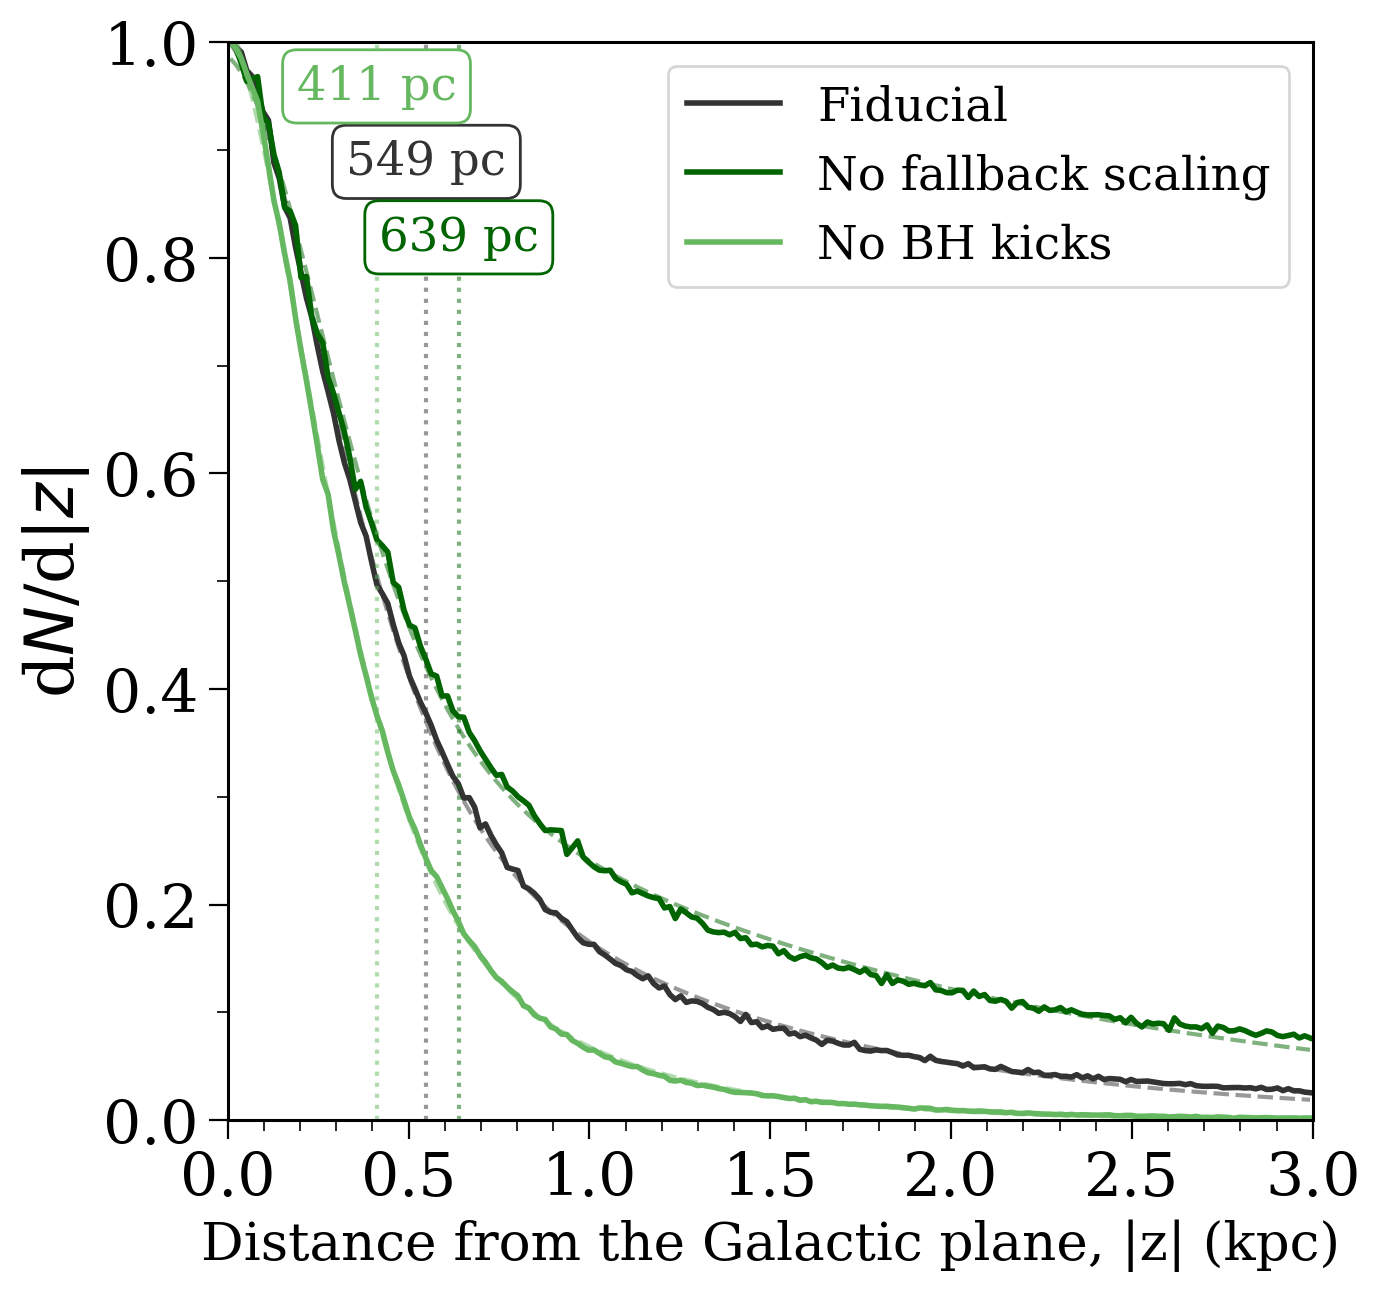

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for pop, loc in zip(pops, [0.98 - 0.07 * 1, 0.98 - 0.07 * 2, 0.98 - 0.07 * 0]):

    plotting.estimate_scale_height(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_kicks.pdf", format="pdf", bbox_inches='tight')

plt.show()

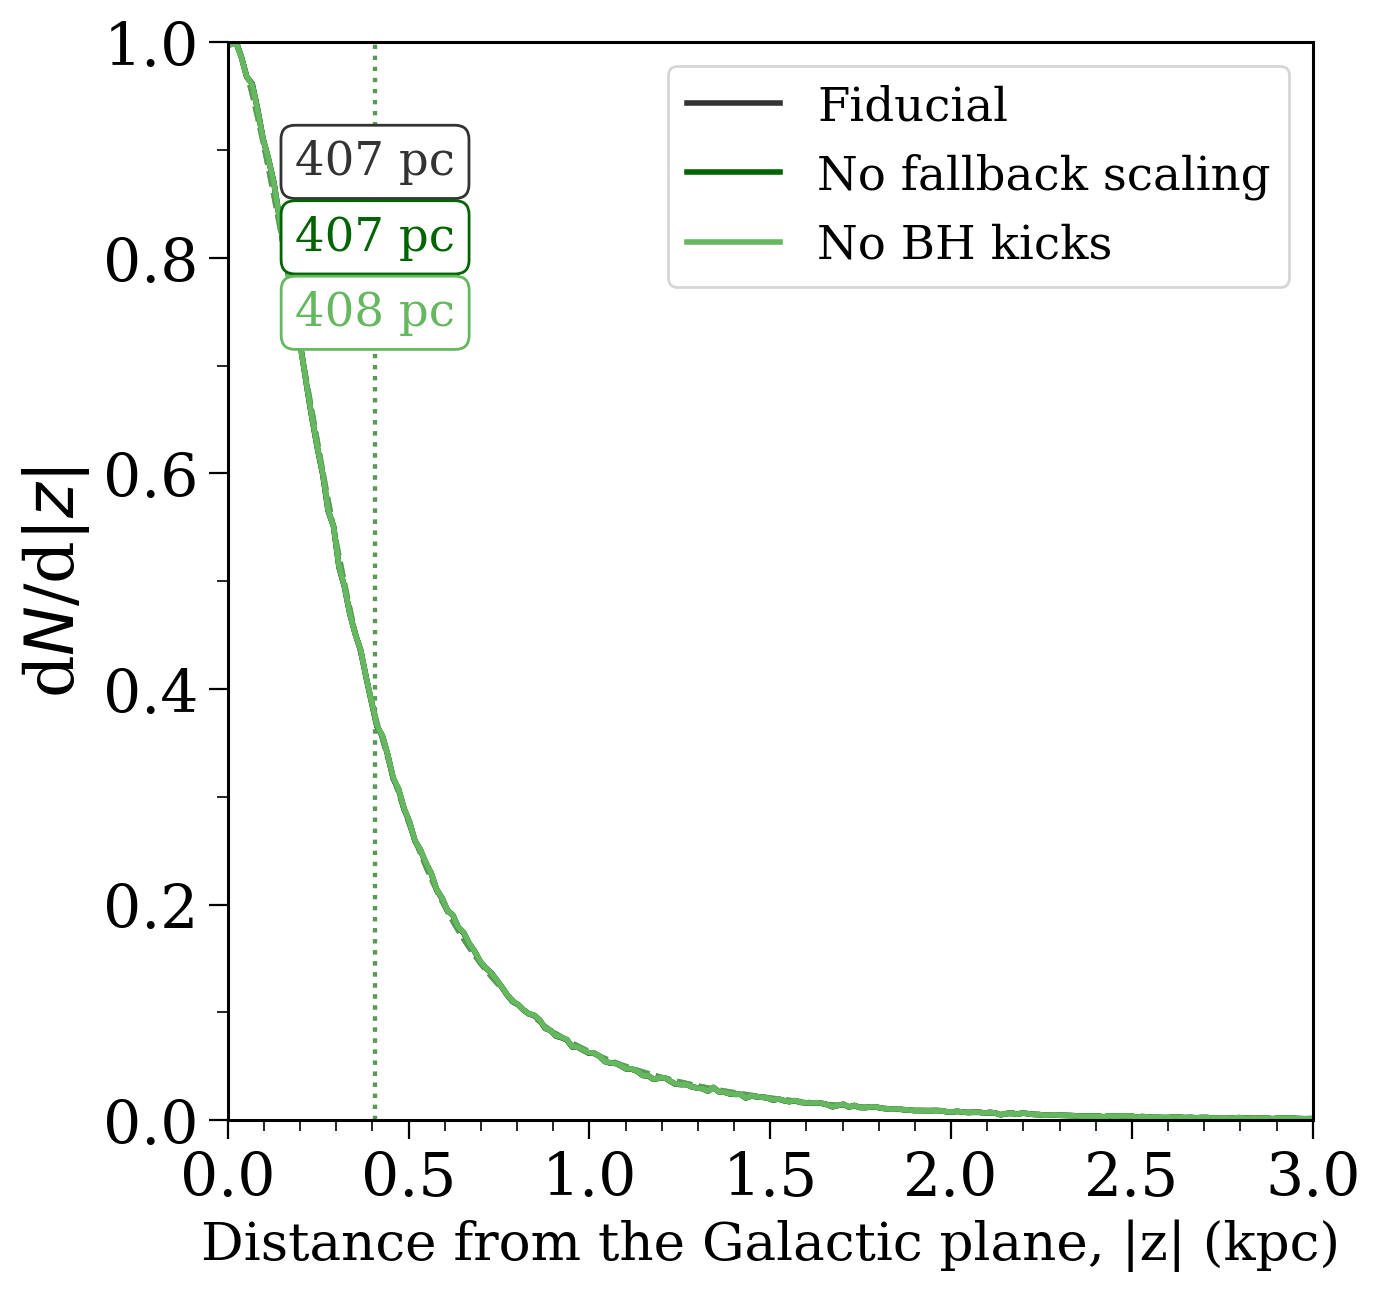

In [16]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for pop, loc in zip(pops, [0.98 - 0.07 * 1, 0.98 - 0.07 * 2, 0.98 - 0.07 * 3, 0.98 - 0.07 * 0]):

    plotting.estimate_scale_height(
        z=data[pop.label]["init_z"]["BH"],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_kicks.pdf", format="pdf", bbox_inches='tight')

plt.show()

In [17]:
print("Average BH masses:")
print("------------------")

for pop in pops:
    mass = data[pop.label]["mass"]

    average_escaped_BH_mass = np.mean(mass["BH"][data[pop.label]["escaped"]["BH"]])
    average_bound_BH_mass = np.mean(mass["BH"][~data[pop.label]["escaped"]["BH"]])

    avg_bound_BH_close_to_disc = np.mean(mass["BH"][(
        ~data[pop.label]["escaped"]["BH"] &
        (abs(data[pop.label]["pos"]["BH"][:, 2]) < 1)
    )])

    avg_bound_BH_far_from_disc = np.mean(mass["BH"][(
        ~data[pop.label]["escaped"]["BH"] &
        (abs(data[pop.label]["pos"]["BH"][:, 2]) >= 1)
    )])

    print(f"{pop.label}")
    print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
    print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
    print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
    print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")
    print()

Average BH masses:
------------------
Fiducial
  Escaped: 5.2 Msun
  Bound:   9.3 Msun
    Close to disc (<1 kpc):  10.1 Msun
    Far from disc (>=1 kpc): 7.7 Msun

No fallback scaling
  Escaped: 9.7 Msun
  Bound:   9.1 Msun
    Close to disc (<1 kpc):  8.3 Msun
    Far from disc (>=1 kpc): 9.6 Msun

No BH kicks
  Escaped: 5.5 Msun
  Bound:   9.2 Msun
    Close to disc (<1 kpc):  9.1 Msun
    Far from disc (>=1 kpc): 10.7 Msun



In [19]:
z_range = np.geomspace(0.1, 10, 500)

init_abs_z = np.abs(data[pops[0].label]["init_z"]["BH"])

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2]) for pop in pops] + [init_abs_z],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data[pops[0].label]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.1
)

z_maxes = [10, 10, 3, 3]

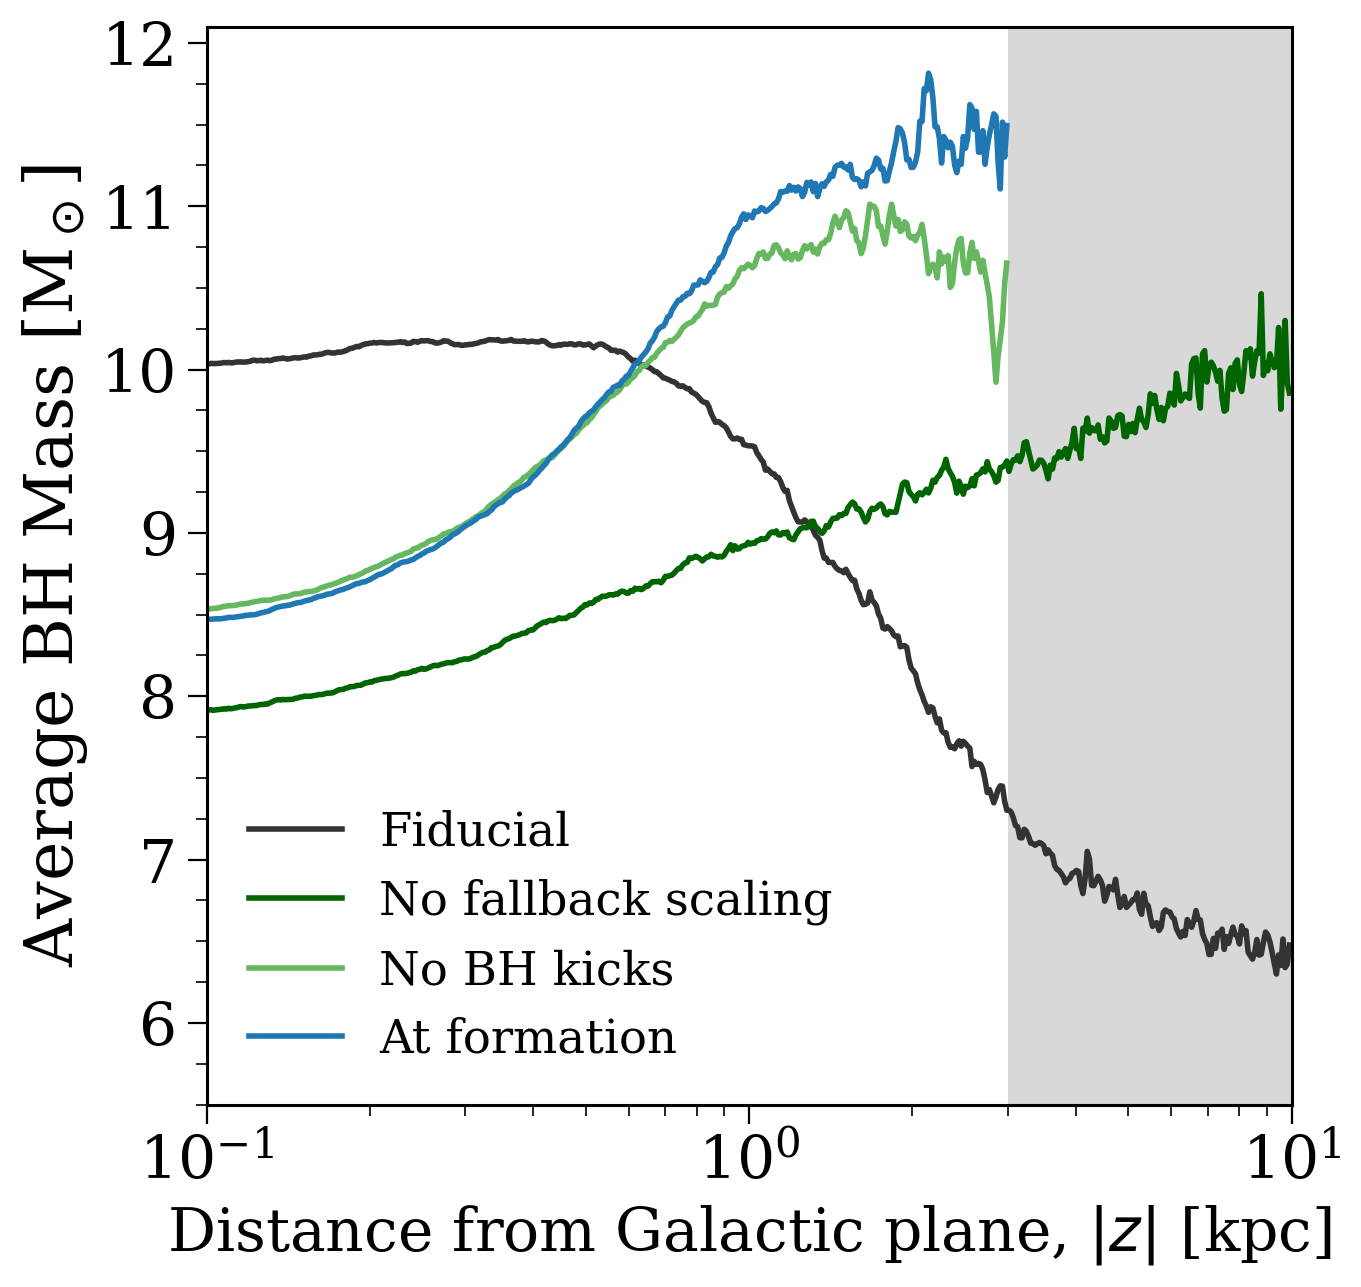

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [26]:
reload(plotting)
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses,
    labels=labels + ["At formation"],
    colours=colours + ["tab:blue"],
    z_maxes=z_maxes,
    z_range=z_range,
    legend_kwargs={
        "title": None,
        "fontsize": 0.7*fs,
        "title_fontsize": 0.6*fs,
        "loc": "lower left",
        "frameon": False
    },
    ax_kwargs={
        "ylim": (5.5, 12.1)
    },
    save="../plots/average_bh_mass_vs_z_kicks.pdf",
)